### Cell 1 Imports & paths

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Paths
PROCESSED_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs/figures")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Cell 2 Load data

In [10]:
# Load session features
session_df = pd.read_parquet(PROCESSED_DIR / "user_sessions.parquet")
print("Session data shape:", session_df.shape)

# Load cluster labels (from K‑Means)
cluster_df = pd.read_csv(PROCESSED_DIR / "user_clusters.csv")
print("Cluster labels shape:", cluster_df.shape)

# Merge cluster labels
session_df = session_df.merge(cluster_df, on=['visitorid', 'session_id'], how='left')
print("After merge shape:", session_df.shape)

# Check distribution of target variable
print("\nPurchase distribution:")
print(session_df['purchased'].value_counts(normalize=True))

Session data shape: (1761675, 11)
Cluster labels shape: (1761675, 3)
After merge shape: (1761675, 12)

Purchase distribution:
purchased
0    0.991884
1    0.008116
Name: proportion, dtype: float64


### Cell 3 Feature Engineering

In [ ]:
# Define feature columns
numeric_features = ['num_views', 'num_addtocart', 
                    'unique_items', 'categories_viewed', 'duration_min']

cluster_dummies = pd.get_dummies(session_df['cluster'], prefix='cluster', dtype=int)
X = pd.concat([session_df[numeric_features], cluster_dummies], axis=1)
y = session_df['purchased']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1761675, 9)
Target shape: (1761675,)


### Cell 4 Temporal Train/Test Split

In [12]:
# Convert start_time to datetime
session_df['start_time'] = pd.to_datetime(session_df['start_time'])

# Get the date range
min_date = session_df['start_time'].min()
max_date = session_df['start_time'].max()
total_days = (max_date - min_date).days
print(f"Date range: {min_date.date()} to {max_date.date()} ({total_days} days)")

# Cutoff: 80% of days from min_date
cutoff_date = min_date + pd.Timedelta(days=int(0.8 * total_days))
print(f"Cutoff date for training: {cutoff_date.date()}")

# Split indices
train_idx = session_df['start_time'] <= cutoff_date
test_idx = session_df['start_time'] > cutoff_date

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Training purchase rate: {y_train.mean():.4f}")
print(f"Test purchase rate: {y_test.mean():.4f}")

Date range: 2015-05-03 to 2015-09-18 (137 days)
Cutoff date for training: 2015-08-20
Training samples: 1421837
Test samples: 339838
Training purchase rate: 0.0082
Test purchase rate: 0.0080


### Cell 5 Train Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Training completed.")

# Save model
joblib.dump(rf, MODEL_DIR / "random_forest.pkl")
print(f"Model saved to {MODEL_DIR / 'random_forest.pkl'}")

Training completed.
Model saved to ..\models\random_forest.pkl


### Cell 6 Model Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9858    0.9927    337130
           1     0.3498    0.9513    0.5115      2708

    accuracy                         0.9855    339838
   macro avg     0.6747    0.9685    0.7521    339838
weighted avg     0.9944    0.9855    0.9888    339838



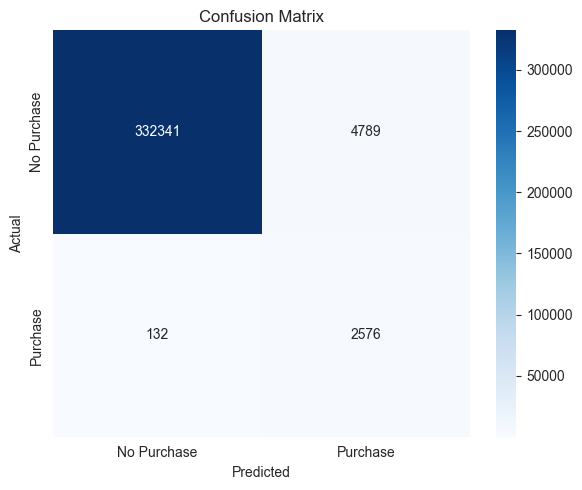

ROC-AUC Score: 0.9967


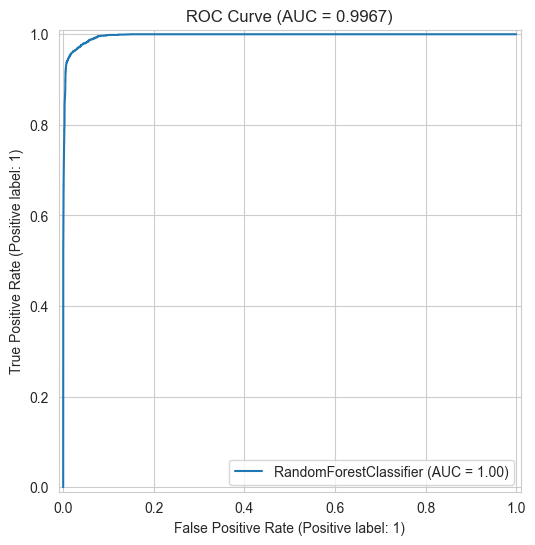

In [14]:
# Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title(f'ROC Curve (AUC = {roc_auc:.4f})')
plt.grid(True)
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=150)
plt.show()

### Cell 7 Feature Importance

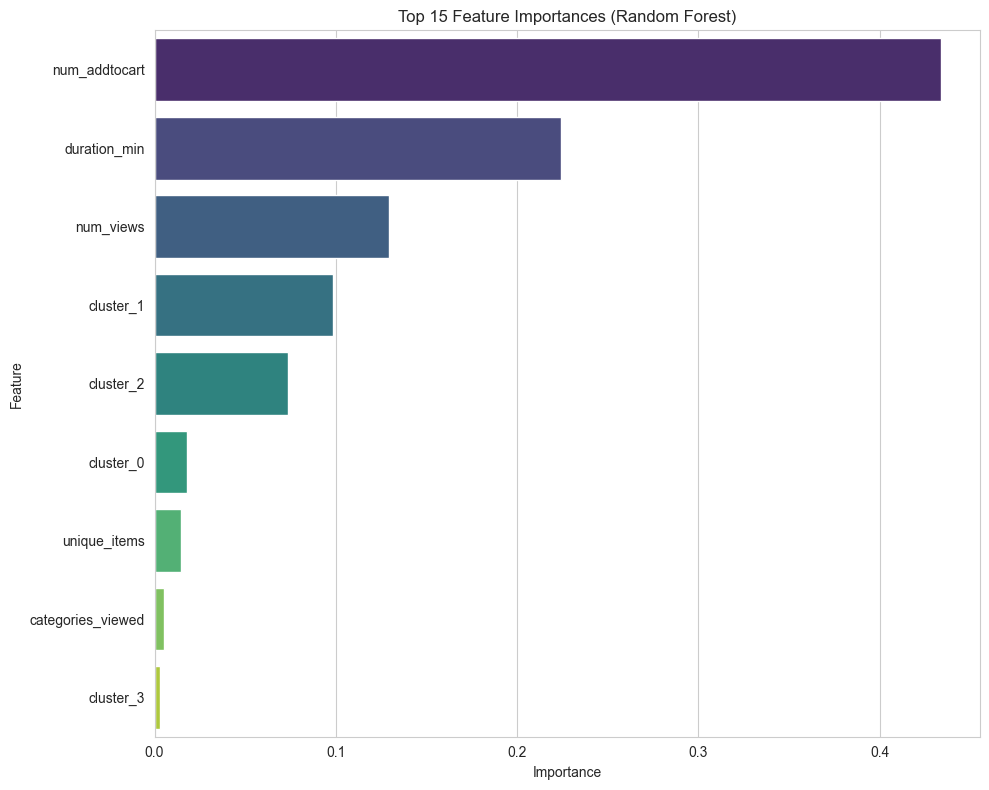

Feature importance saved to ..\models\feature_importance.json


In [15]:
# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create DataFrame
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_feature_importance.png", dpi=150)
plt.show()

# Save feature importance to JSON (for the main app)
importance_dict = dict(zip(feature_names, importances))
with open(MODEL_DIR / "feature_importance.json", "w") as f:
    json.dump(importance_dict, f, indent=2)
print("Feature importance saved to", MODEL_DIR / "feature_importance.json")

### Cell 8 Save Evaluation Metrics Summary

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'accuracy': rf.score(X_test, y_test),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc
}
print("Evaluation metrics:", metrics)

with open(MODEL_DIR / "rf_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved to", MODEL_DIR / "rf_metrics.json")

Evaluation metrics: {'accuracy': 0.9855195710897545, 'precision': 0.34976238968092327, 'recall': 0.9512555391432792, 'f1': 0.5114662960389159, 'roc_auc': 0.9967424652119303}
Metrics saved to ..\models\rf_metrics.json
